In [3]:
from config import TrainConfig, DataConfig, PathConfig
from losses import get_loss
from dataset import get_dataloader, load_dataset
from utils import load_thresholds

from models.efficientnetv2 import TransferEfficientNetV2

import torch
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    f1_score, precision_recall_curve, average_precision_score, 
)
from utils import load_checkpoint

In [4]:
def evaluate(model: nn.Module, criterion: nn.Module, test_loader: DataLoader, 
             thresholds: torch.Tensor, device: str = TrainConfig.device) -> dict:
    assert len(thresholds) == DataConfig.n_classes, "The num of thresholds must be equal to the num of classes"
    thresholds = thresholds.to(device)
    
    model.eval()
    eval_pbar = tqdm(test_loader, leave=False)
    with torch.no_grad():
        targets, probabilities, predictions = [], [], []
        total_loss = 0
        
        for imgs, lbls in eval_pbar:
            imgs = imgs.to(device)
            lbls = lbls.to(device)

            out = model(imgs)
            loss = criterion(out, lbls)

            probs = torch.sigmoid(out)
            preds = (probs >= thresholds).int()

            targets.append(lbls.cpu().numpy())
            probabilities.append(probs.cpu().numpy())
            predictions.append(preds.cpu().numpy())
            
            total_loss += loss.item() * imgs.shape[0]

        targets = np.vstack(targets)
        probabilities = np.vstack(probabilities)
        predictions = np.vstack(predictions)

        total_loss /= len(test_loader.sampler)
        f1_macro = f1_score(targets, predictions, average='macro', zero_division=0)
        f1_micro = f1_score(targets, predictions, average='micro', zero_division=0)
        f1_samples = f1_score(targets, predictions, average='samples', zero_division=0)

        return {
            "targets": targets,
            "probabilities": probabilities,
            "predictions": predictions,
            "loss": total_loss,
            "f1_macro": f1_macro,
            "f1_micro": f1_micro,
            "f1_samples": f1_samples
        }

In [5]:
class_labels = [
    "Nucleoplasm",
    "Nuclear membrane",
    "Nucleoli",
    "Nucleoli fibrillar center",
    "Nuclear speckles",
    "Nuclear bodies",
    "Endoplasmic reticulum",
    "Golgi apparatus",
    "Peroxisomes",
    "Endosomes",
    "Lysosomes",
    "Intermediate filaments",
    "Actin filaments",
    "Focal adhesion sites",
    "Microtubules",
    "Microtubule ends",
    "Cytokinetic bridge",
    "Mitotic spindle",
    "Microtubule organizing center",
    "Centrosome",
    "Lipid droplets",
    "Plasma membrane",
    "Cell junctions",
    "Mitochondria",
    "Aggresome",
    "Cytosol",
    "Cytoplasmic bodies",
    "Rods & ring"
]

In [6]:
def plot_pr_curves(targets: np.ndarray, probs: np.ndarray):
    n = DataConfig.n_classes
    n_rows = (n + 2) // 3
    n_cols = 3
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.ravel()

    for cls_idx in range(n):
        precision, recall, _ = precision_recall_curve(targets[:, cls_idx], probs[:, cls_idx])
        ap = average_precision_score(targets[:, cls_idx], probs[:, cls_idx])
        
        axes[cls_idx].plot(recall, precision, linewidth=2, color='blue')
        axes[cls_idx].fill_between(recall, precision, alpha=0.2, color='blue')
        axes[cls_idx].set_title(f'{class_labels[cls_idx]}\nAP={ap:.3f}')
        axes[cls_idx].set_xlabel('Recall')
        axes[cls_idx].set_ylabel('Precision')
        axes[cls_idx].set_xlim([0.0, 1.0])
        axes[cls_idx].set_ylim([0.0, 1.05])
        axes[cls_idx].grid(True, alpha=0.2)

    for i in range(n, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

In [7]:
def plot_f1_comparison(targets: np.ndarray, predictions: np.ndarray):
    n = DataConfig.n_classes
    f1_scores = []
    
    for cls_idx in range(n):
        f1 = f1_score(targets[:, cls_idx], predictions[:, cls_idx])
        f1_scores.append(f1)
    
    macro_f1 = np.mean(f1_scores)
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(n)
    bars = ax.bar(x, f1_scores, color='steelblue', alpha=0.8, edgecolor='black')
    ax.axhline(y=macro_f1, color='red', linestyle='--', linewidth=2, 
               label=f'Macro F1 = {macro_f1:.3f}')
    
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('F1 Score', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(class_labels, rotation=45, ha='right')
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

In [ ]:
name = "env2_focal2.2_e20"
model, _ = load_checkpoint(name, TransferEfficientNetV2())
criterion = get_loss()
test_loader = get_dataloader(
    load_dataset(PathConfig.valid_ds_path),
    batch_size=DataConfig.valid_batch,
    shuffle=False
)
thresholds = load_thresholds(name)

In [14]:
# evaluate loss-opt
result = evaluate(model, criterion, test_loader, thresholds, device=TrainConfig.device)

targets = result["targets"]
probabilities = result["probabilities"]
predictions = result["predictions"]
loss = result["loss"]
f1_macro = result["f1_macro"]
f1_micro = result["f1_micro"]
f1_samples = result["f1_samples"]

print(f"Avarage loss of the model: {loss}")
print(f"F1-metrics:\n\tF1-macro={f1_macro:3f}\n\tF1-micro={f1_micro:3f}\n\tF1-samples={f1_samples:3f}")

Avarage loss of the model: 0.004123926182300207
F1-metrics:
	F1-macro=0.596042
	F1-micro=0.695526
	F1-samples=0.692041


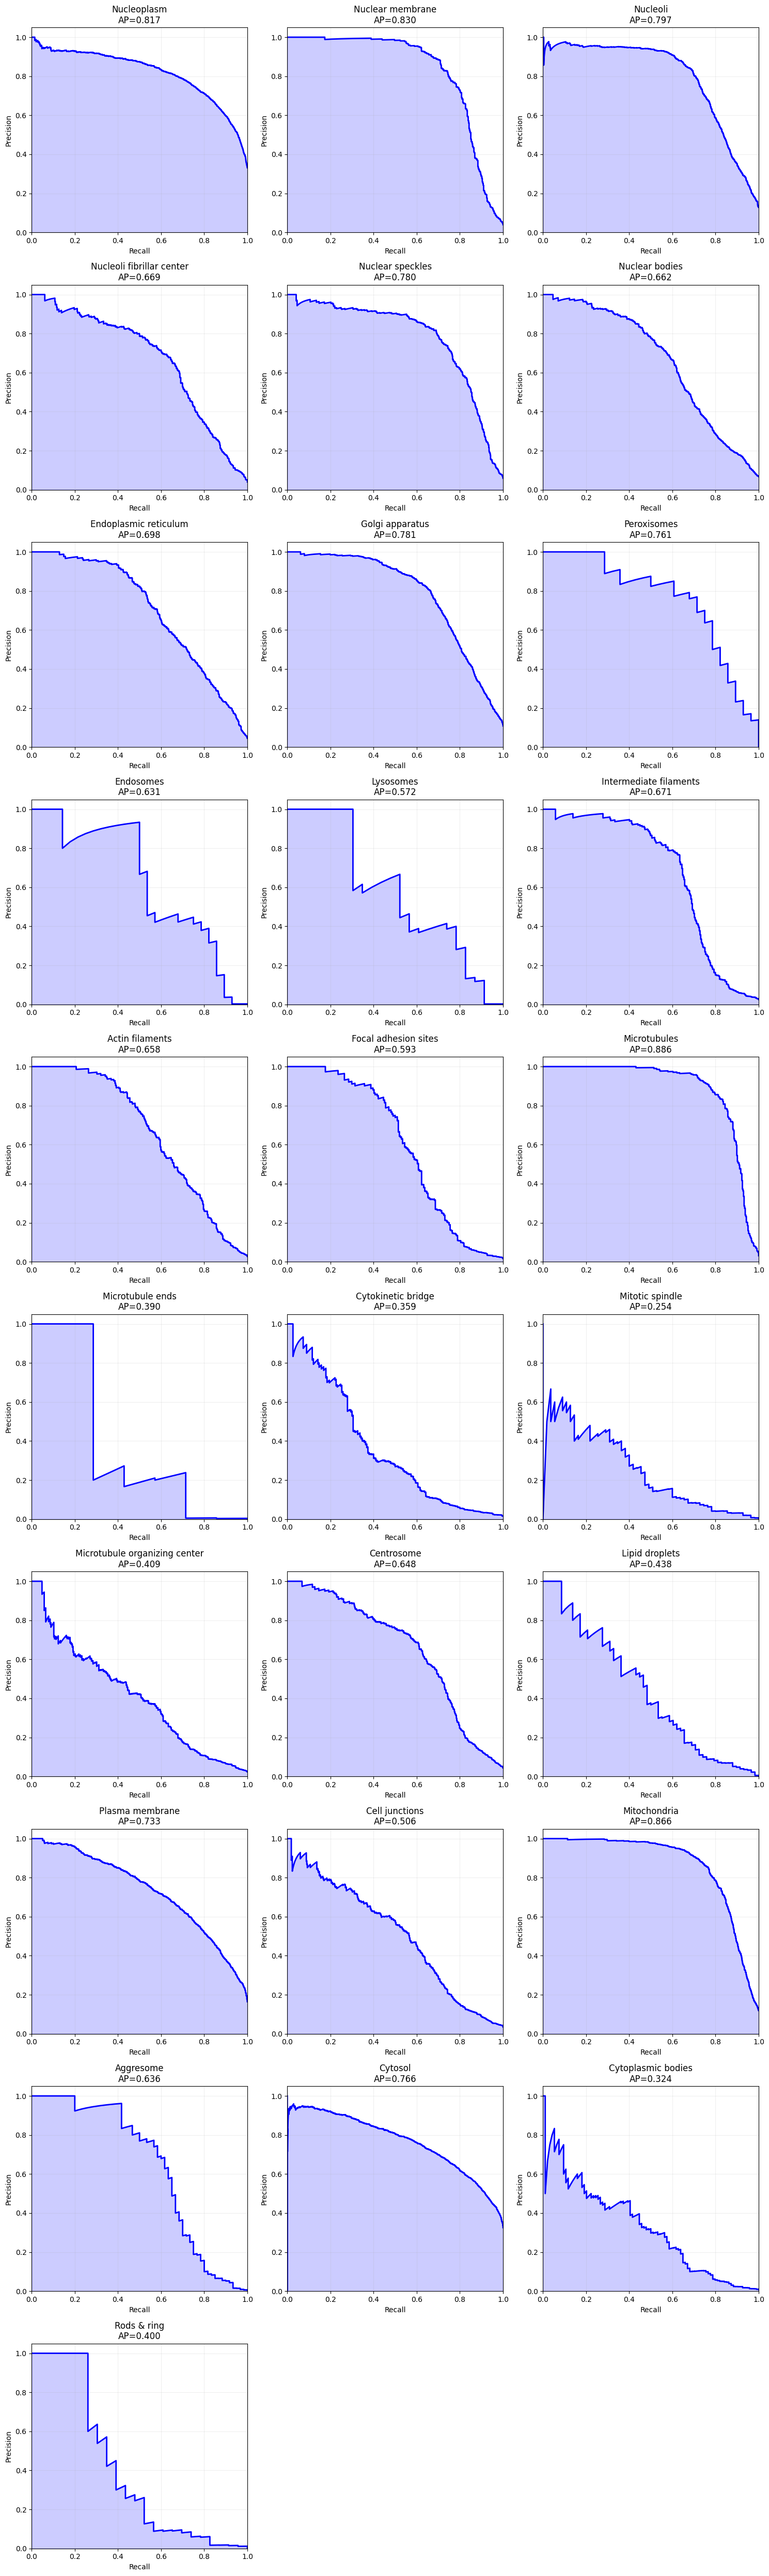

In [15]:
plot_pr_curves(targets, probabilities)

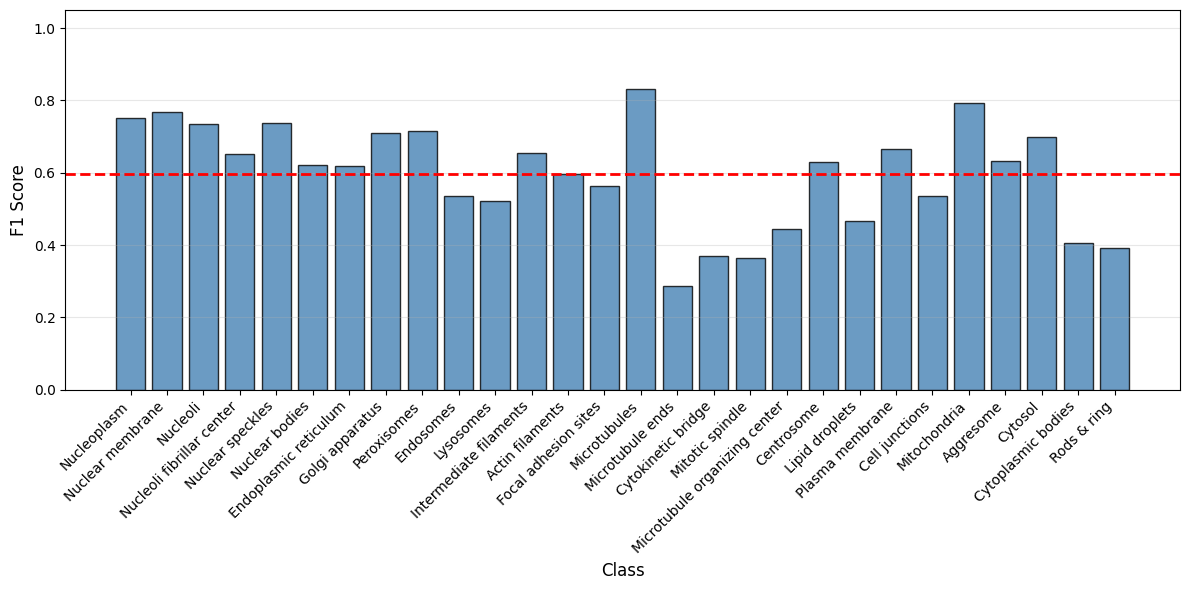

In [17]:
plot_f1_comparison(targets, predictions)